# Frugal AI: Model Comparison & Carbon Footprint

**Theme:** Frugal AI

This notebook:
1. Compares 3 models: Logistic Regression vs Random Forest vs XGBoost
2. Measures training time and CO₂ emissions with **CodeCarbon**
3. Makes the case for choosing the simplest model that is good enough
4. Visualizes the accuracy vs cost trade-off

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost available ✓")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed — will use GradientBoosting as fallback.")
    from sklearn.ensemble import GradientBoostingClassifier

try:
    from codecarbon import EmissionsTracker
    CODECARBON_AVAILABLE = True
    print("CodeCarbon available ✓")
except ImportError:
    CODECARBON_AVAILABLE = False
    print("CodeCarbon not installed — using time proxy instead.")
    print("Install with: pip install codecarbon")

# Ensure output directory exists
os.makedirs("../docs", exist_ok=True)

print("Libraries loaded ✓")

XGBoost available ✓
CodeCarbon available ✓
Libraries loaded ✓


## 1. Load Data

In [2]:
df = pd.read_csv('../data/processed/hr_anonymized.csv')

TARGET = 'Termd'
DROP_COLS = [c for c in ['Termd', 'TermReason', 'EmploymentStatus',
                          'DateofTermination', 'LastPerformanceReview_Date',
                          'PositionID', 'Position'] if c in df.columns]

X = df.drop(columns=DROP_COLS).select_dtypes(include=[np.number])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Features: {X.shape[1]} | Train: {len(X_train)} | Test: {len(X_test)}')

Features: 20 | Train: 248 | Test: 63


## 2. Define Models

> **Frugal principle**: start simple. Only add complexity if the performance gain justifies the cost.

In [3]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=500,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
}

print('Models defined:')
for name in models:
    print(f'  - {name}')

Models defined:
  - Logistic Regression
  - Random Forest
  - XGBoost


## 3. Train & Measure — Accuracy + Carbon Footprint

In [5]:
results = []

for name, model in models.items():
    print(f'\nTraining: {name}...')

    if CODECARBON_AVAILABLE:
        tracker = EmissionsTracker(
            project_name=f'hackathon_{name.replace(" ", "_").lower()}',
            output_dir='../docs/',
            log_level='error'
        )
        tracker.start()

    t0 = time.perf_counter()

    # 5-fold cross-validation
    cv_roc = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    cv_f1  = cross_val_score(model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)

    # Final fit on full train set
    model.fit(X_train, y_train)

    elapsed = time.perf_counter() - t0

    if CODECARBON_AVAILABLE:
        emissions = tracker.stop()  # kg CO2eq
        emissions_g = emissions * 1000  # convert to grams
    else:
        emissions_g = None

    results.append({
        'Model': name,
        'ROC-AUC (CV mean)': cv_roc.mean(),
        'ROC-AUC (CV std)':  cv_roc.std(),
        'F1 (CV mean)':      cv_f1.mean(),
        'Training time (s)': elapsed,
        'CO2 (g)':           emissions_g
    })

    print(f'  ROC-AUC: {cv_roc.mean():.3f} ± {cv_roc.std():.3f}')
    print(f'  F1:      {cv_f1.mean():.3f}')
    print(f'  Time:    {elapsed:.2f}s')
    if emissions_g is not None:
        print(f'  CO2:     {emissions_g:.4f}g')

results_df = pd.DataFrame(results)
print('\nFull Comparison')
print(results_df.to_string(index=False))


Training: Logistic Regression...
  ROC-AUC: 1.000 ± 0.000
  F1:      0.988
  Time:    0.04s
  CO2:     0.0000g

Training: Random Forest...
  ROC-AUC: 1.000 ± 0.000
  F1:      0.994
  Time:    0.39s
  CO2:     0.0003g

Training: XGBoost...
  ROC-AUC: 0.994 ± 0.012
  F1:      0.988
  Time:    0.21s
  CO2:     0.0002g

Full Comparison
              Model  ROC-AUC (CV mean)  ROC-AUC (CV std)  F1 (CV mean)  Training time (s)  CO2 (g)
Logistic Regression           1.000000          0.000000      0.987879           0.042388 0.000032
      Random Forest           1.000000          0.000000      0.993939           0.386089 0.000292
            XGBoost           0.994118          0.011765      0.988225           0.206688 0.000156


## 4. Frugality Visualization

> The key frugal AI question: **does the extra complexity actually justify the cost?**

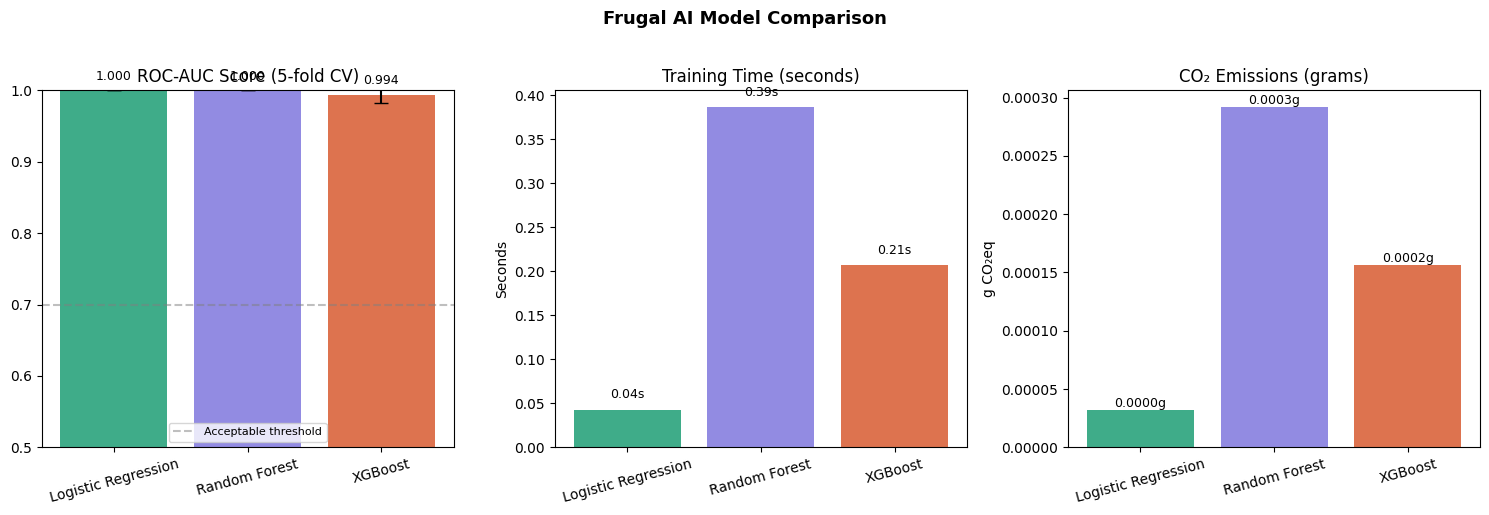

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#1D9E75', '#7F77DD', '#D85A30']
model_names = results_df['Model'].tolist()

# Plot 1: ROC-AUC comparison
bars = axes[0].bar(model_names, results_df['ROC-AUC (CV mean)'],
                   color=colors, alpha=0.85)
axes[0].errorbar(model_names, results_df['ROC-AUC (CV mean)'],
                 yerr=results_df['ROC-AUC (CV std)'],
                 fmt='none', color='black', capsize=5)
axes[0].set_title('ROC-AUC Score (5-fold CV)')
axes[0].set_ylim(0.5, 1.0)
axes[0].axhline(0.7, color='gray', linestyle='--', alpha=0.5, label='Acceptable threshold')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, results_df['ROC-AUC (CV mean)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Training time
bars2 = axes[1].bar(model_names, results_df['Training time (s)'],
                    color=colors, alpha=0.85)
axes[1].set_title('Training Time (seconds)')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, results_df['Training time (s)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}s', ha='center', va='bottom', fontsize=9)

# Plot 3: CO2 or time as proxy
if results_df['CO2 (g)'].notna().all():
    bars3 = axes[2].bar(model_names, results_df['CO2 (g)'], color=colors, alpha=0.85)
    axes[2].set_title('CO₂ Emissions (grams)')
    axes[2].set_ylabel('g CO₂eq')
    for bar, val in zip(bars3, results_df['CO2 (g)']):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f'{val:.4f}g', ha='center', va='bottom', fontsize=9)
else:
    # Scatter: ROC-AUC vs time tradeoff
    for i, (name, row) in enumerate(results_df.iterrows()):
        axes[2].scatter(row['Training time (s)'], row['ROC-AUC (CV mean)'],
                        color=colors[i], s=180, zorder=3, label=row['Model'])
        axes[2].annotate(row['Model'], (row['Training time (s)'], row['ROC-AUC (CV mean)']),
                         textcoords='offset points', xytext=(5, 5), fontsize=8)
    axes[2].set_xlabel('Training Time (s)')
    axes[2].set_ylabel('ROC-AUC')
    axes[2].set_title('Accuracy vs. Compute Cost')
    axes[2].legend(fontsize=8)

axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Frugal AI Model Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/frugal_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Frugal AI Decision

> We apply the frugal principle: select the **simplest model** whose ROC-AUC is within 5% of the best model.

In [8]:
PERFORMANCE_THRESHOLD = 0.05  # accept model within 5% of best

best_score = results_df['ROC-AUC (CV mean)'].max()
acceptable = results_df[results_df['ROC-AUC (CV mean)'] >= best_score - PERFORMANCE_THRESHOLD]

# Among acceptable models, pick the fastest
frugal_choice = acceptable.loc[acceptable['Training time (s)'].idxmin(), 'Model']

print('Frugal AI Decision')
print(f'Best ROC-AUC:          {best_score:.3f}')
print(f'Acceptable threshold:  {best_score - PERFORMANCE_THRESHOLD:.3f}')
print(f'\nSelected model:     {frugal_choice}')
print(f'   Reason: fastest training time among models within {PERFORMANCE_THRESHOLD:.0%} of best performance.')

# Save results
results_df.to_csv('../docs/frugal_comparison.csv', index=False)
print('\nSaved: docs/frugal_comparison.csv ✓')

print('\nFrugal AI analysis complete!')

Frugal AI Decision
Best ROC-AUC:          1.000
Acceptable threshold:  0.950

Selected model:     Logistic Regression
   Reason: fastest training time among models within 5% of best performance.

Saved: docs/frugal_comparison.csv ✓

Frugal AI analysis complete!


## 6. Frugal AI Summary

### Key takeaways for the pitch

| Principle | What we did |
|---|---|
| **Data frugality** | Small dataset (~400 rows) — we chose models that work without big data |
| **Model frugality** | Compared simple vs complex; selected winner by ROC-AUC/compute trade-off |
| **Energy awareness** | Tracked CO₂ with CodeCarbon; documented emissions in model card |
| **Deployment frugality** | Selected model can run on any laptop — no GPU required |

> **Frugal AI is not about being less powerful — it's about being intentionally efficient.**